# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [46]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [47]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [48]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [49]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)

print("Число :", random.randint(1, 100))
random.shuffle(numbers)
print("Ліст :", numbers)

print("Число :", random.randint(1, 100))
random.shuffle(numbers)
print("Ліст:", numbers)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням
set_seed(SEED)
numbers = list(range(10))
print("Число 1:", random.randint(1, 100))
random.shuffle(numbers)
print("Ліст 1:", numbers)

set_seed(SEED)
numbers = list(range(10))
print("Число 2 (1):", random.randint(1, 100))
random.shuffle(numbers)
print("Ліст 2 (1):", numbers)

# TODO: тепер ще двічі без проміжних викликів set_seed()
set_seed(SEED)
numbers = list(range(10))
print("Число 3 (1):", random.randint(1, 100))
random.shuffle(numbers)
print("Ліст 3 (1):", numbers)

print("Число 4", random.randint(1, 100))
random.shuffle(numbers)
print("Число 4:", numbers)




Число : 65
Ліст : [2, 1, 8, 7, 4, 6, 5, 3, 0, 9]
Число : 76
Ліст: [1, 5, 0, 9, 3, 7, 6, 8, 2, 4]
Число 1: 82
Ліст 1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Число 2 (1): 82
Ліст 2 (1): [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Число 3 (1): 82
Ліст 3 (1): [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Число 4 76
Число 4: [5, 8, 2, 1, 6, 3, 4, 0, 7, 9]


Після `set_seed()` для генерації псевдовипадкових чисел встановлюється початковий стан, від якого буде рухатись кожна генерація, відповідно щоразу як ми скидуємо seed до того ж значення, що і до цього - ми отримуємо такий самий результат. При не змінні seed генерація продовжується по вже фіксованому ланцюжку і значення відповідно різняться.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [50]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [51]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [52]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
zeros_arr = np.zeros((3,4))
sevens_arr = np.full((3,4),7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [53]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
arange_arr = np.arange(0,20,2)
linspace_arr = np.linspace(0,1,5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [54]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
identity = np.eye(4)
random_ints = np.random.randint(0,10,size=(3,3))

print(identity)
print(random_ints)
print("---.ndim---")
print(identity.ndim)
print(random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]
---.ndim---
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [55]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [56]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3,4)
row_sums = matrix.sum(1)
col_sums = matrix.sum(0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [57]:
df = pd.DataFrame({"student": ["Жеребцов Дмитро", "Сапацінський Богдан", "Кухар Артем", "Павленко Павло", "Сергійко Василь", "Вовчук Володимир", "Степаненко Степан"],
                   "score": [72, 80, 85, 65, 77, 97, 100]}) # додай тут дані для DataFrame

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
top = df[df["score"] >= 80].sort_values(by='score', ascending = False)
print(top)


               student  score
6    Степаненко Степан    100
5     Вовчук Володимир     97
2          Кухар Артем     85
1  Сапацінський Богдан     80


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [58]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"

def scoreToGrade(score):
  if(score >= 90):
    return "A"
  elif(score >= 75):
    return "B"
  elif(score >= 60):
      return "C"
  else:
    return "E"

df["grade"] = df["score"].apply(scoreToGrade)
print(df)


               student  score grade
0      Жеребцов Дмитро     72     C
1  Сапацінський Богдан     80     B
2          Кухар Артем     85     B
3       Павленко Павло     65     C
4      Сергійко Василь     77     B
5     Вовчук Володимир     97     A
6    Степаненко Степан    100     A


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [59]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2,3))
sevens_t = torch.full((2,3),7)

print(zeros_t)
print(sevens_t)

print("zeros_t shape:", zeros_t.shape)
print("sevens_t shape:", sevens_t.shape)

print("zeros_t dtype:", zeros_t.dtype)
print("sevens_t dtype:", sevens_t.dtype)


tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[7, 7, 7],
        [7, 7, 7]])
zeros_t shape: torch.Size([2, 3])
sevens_t shape: torch.Size([2, 3])
zeros_t dtype: torch.float32
sevens_t dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [60]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [61]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print(random_t)

print("zeros_t shape:", zeros_t.shape)
print("sevens_t shape:", sevens_t.shape)

print("zeros_t dtype:", zeros_t.dtype)
print("sevens_t dtype:", sevens_t.dtype)

print("zeros_t ndim :", zeros_t.ndim )
print("sevens_t ndim :", sevens_t.ndim )


tensor([[1, 2],
        [3, 4]])
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
zeros_t shape: torch.Size([2, 3])
sevens_t shape: torch.Size([2, 3])
zeros_t dtype: torch.float32
sevens_t dtype: torch.int64
zeros_t ndim : 2
sevens_t ndim : 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [62]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
# надрукувати x.grad.item() і порівняти з 2 * n

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний градієнт:", 2 * n)


Автоматичний градієнт: 10.0
Аналітичний градієнт: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [63]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
for step in range(10):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()


print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.6779  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

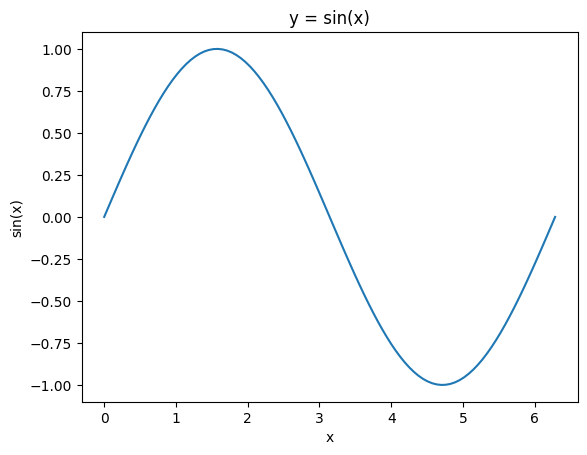

In [64]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()

xs = np.linspace(0, 2 * np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.title("y = sin(x)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

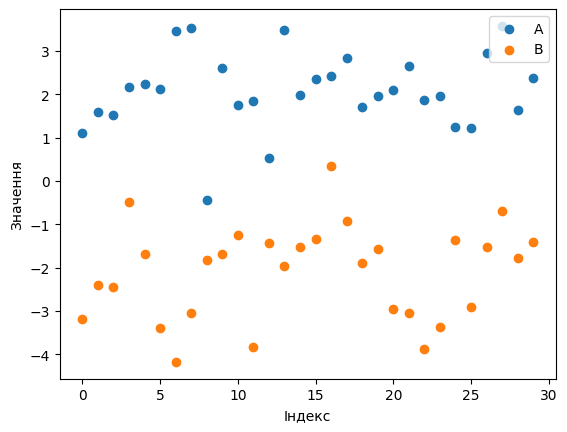

In [65]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()

plt.scatter(range(30), group_a, color="C0", label="A")
plt.scatter(range(30), group_b, color="C1", label="B")
plt.xlabel("Індекс")
plt.ylabel("Значення")
plt.legend(loc=1)
plt.show()

---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [66]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

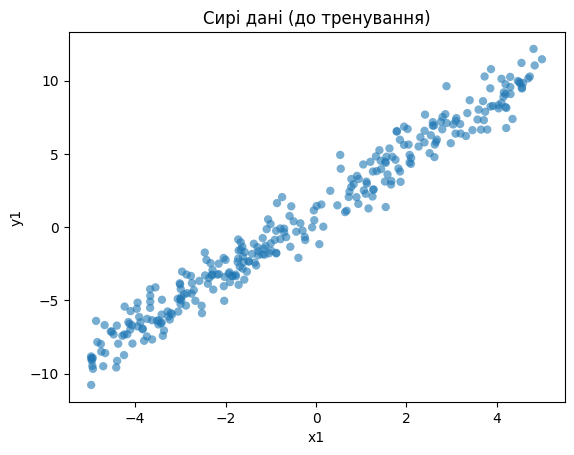

In [67]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.scatter(x1.numpy(), y1.numpy(), alpha=0.6, edgecolors="none")
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [68]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...

indices = torch.randperm(TASK1_N)
train_end = int(0.70 * TASK1_N)
val_end = int(0.85 * TASK1_N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

x_train1, y_train1 = x1[train_idx], y1[train_idx]
x_val1, y_val1 = x1[val_idx], y1[val_idx]
x_test1, y_test1 = x1[test_idx], y1[test_idx]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [69]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


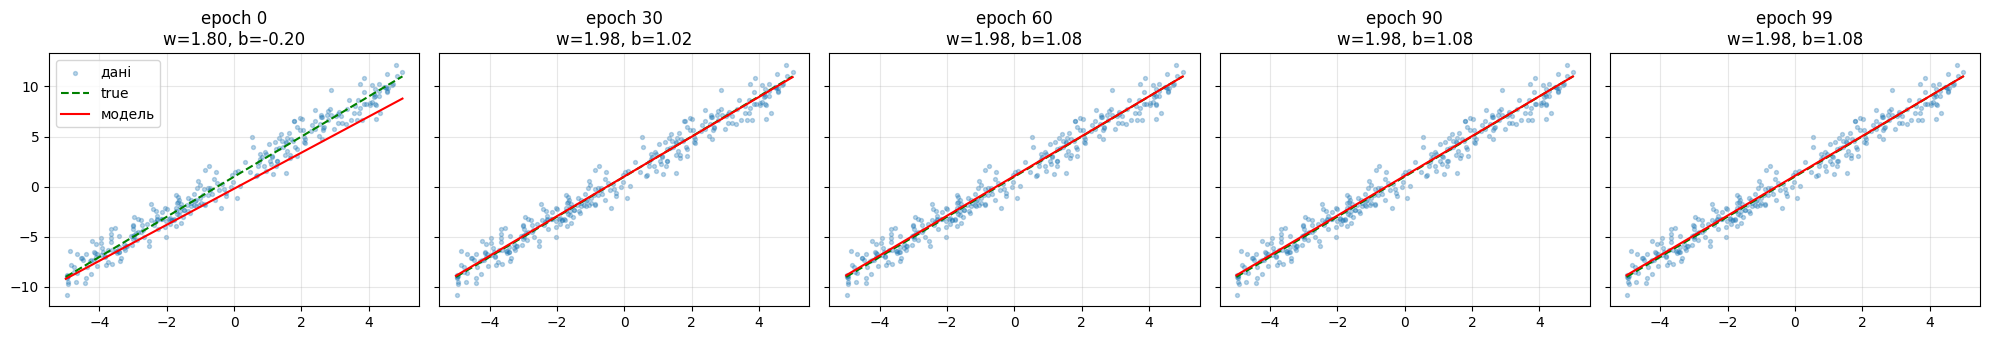

In [70]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

**Власний сценарій**
Нехай буде залежність загальної кількості спалених калорій за добу `(y, ккал) `від кількості пройдених кроків `(x, у тисячах кроків)`.

$$y = w \cdot x + b + \varepsilon$$

$b = 1650.0$ (ккал) — базовий рівень метаболізму (BMR) середньостатистичної людини. Це енергія, яку тіло спалює у стані спокою на дихання, роботу мозку та внутрішніх органів навіть за нульової рухової активності.

$w = 42.0$ (ккал / 1 000 кроків) — середня енергетична вартість ходьби. За стандартної ваги (70–75 кг) 1 000 кроків спалюють орієнтовно 40–45 ккал.

Шум ($\sigma = 65.0$ ккал) — моделює природні коливання: темп ходьби, підйоми сходами чи вгору, термічний ефект вжитої їжі (TEF).

Дані брав від GPT, але перевірив і звучить все правдоподібно)

In [71]:
TRUE_W = 42.0
TRUE_B = 1650.0
N_SAMPLES = 500

set_seed(42)

steps_k = torch.empty(N_SAMPLES, 1).uniform_(2.0, 25.0)
noise = torch.randn(N_SAMPLES, 1) * 65.0
calories = TRUE_W * steps_k + TRUE_B + noise

calories_df = pd.DataFrame({
    "steps_k": steps_k.squeeze().numpy(),
    "calories_burned": calories.squeeze().numpy()
})
calories_df.to_csv("dataset.csv", index=False)
calories_df.to_csv(os.path.join(ARTIFACT_DIR, "dataset.csv"), index=False)
print("Dataset is saved ")


def split_data(x: torch.Tensor, y: torch.Tensor, train_ratio: float = 0.70, val_ratio: float = 0.15):
    n = len(x)
    perm = torch.randperm(n)
    t_end = int(train_ratio * n)
    v_end = int((train_ratio + val_ratio) * n)
    return (
        x[perm[:t_end]], y[perm[:t_end]],
        x[perm[t_end:v_end]], y[perm[t_end:v_end]],
        x[perm[v_end:]], y[perm[v_end:]]
    )


def train_linear_model(x_tr, y_tr, x_val, y_val, epochs=1500, lr=5.0):
    model = torch.nn.Linear(1, 1)

    with torch.no_grad():
        model.bias.fill_(y_tr.mean().item())
        model.weight.fill_(0.0)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(x_tr), y_tr)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 300 == 0:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(x_val), y_val).item()
            print(f"Епоха {epoch+1:4d} | Train MSE: {loss.item():.2f} | Val MSE: {val_loss:.2f}")

    return model


def evaluate_model(model, x_te, y_te):
    model.eval()
    loss_fn = torch.nn.MSELoss()
    with torch.no_grad():
        test_loss = loss_fn(model(x_te), y_te).item()
        test_mae = torch.mean(torch.abs(model(x_te) - y_te)).item()

    w_pred = model.weight.item()
    b_pred = model.bias.item()

    print("\nTest:")
    print(f"Test MSE Loss : {test_loss:.2f}")
    print(f"Test MAE      : {test_mae:.2f} kkal")
    print(f"w    : {w_pred:.2f}  (true {TRUE_W})")
    print(f"b    : {b_pred:.2f}  (true {TRUE_B})")


x_tr, y_tr, x_val, y_val, x_te, y_te = split_data(steps_k, calories)
trained_model = train_linear_model(x_tr, y_tr, x_val, y_val)
evaluate_model(trained_model, x_te, y_te)

Dataset is saved 
Епоха  300 | Train MSE: 4166.96 | Val MSE: 4074.49
Епоха  600 | Train MSE: 4166.73 | Val MSE: 4070.83
Епоха  900 | Train MSE: 4166.73 | Val MSE: 4070.83
Епоха 1200 | Train MSE: 4166.73 | Val MSE: 4070.83
Епоха 1500 | Train MSE: 4166.73 | Val MSE: 4070.83

Test:
Test MSE Loss : 3002.97
Test MAE      : 45.28 kkal
w    : 42.03  (true 42.0)
b    : 1649.87  (true 1650.0)


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

**Збереження моделі:**

In [72]:

torch.save(trained_model, "model.pt")
torch.save(trained_model, os.path.join(ARTIFACT_DIR, "model.pt"))
print("Model is successfully saved")

Model is successfully saved


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [73]:
!pip install -q gradio

import gradio as gr
import os
import torch

model_path = (
    os.path.join(ARTIFACT_DIR, "model.pt")
    if "ARTIFACT_DIR" in locals() and os.path.exists(os.path.join(ARTIFACT_DIR, "model.pt"))
    else "model.pt"
)

model = torch.load(model_path, weights_only=False)
model.eval()


def predict_calories(steps: float) -> str:
    if steps is None or steps < 0:
        return "Введіть коректну кількість кроків (>= 0)"

    steps_k = steps / 1000.0

    input_tensor = torch.tensor([[steps_k]], dtype=torch.float32)

    with torch.no_grad():
        prediction = model(input_tensor).item()

    return f"{prediction:.1f} ккал"


demo = gr.Interface(
    fn=predict_calories,
    inputs=gr.Number(
        label="Кількість кроків за день",
        value=10000,
        minimum=0,
        maximum=50000,
        step=500,
    ),
    flagging_mode="never",
    outputs=gr.Textbox(
        label="Прогнозовано спалені калорії",
    ),
    title="Калькулятор спалених калорій",
    examples=[[5000], [10000], [15000], [20000]],
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cc776ff056ebd3337.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```